In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math
import seaborn as sns
import warnings

# Загрузка предобработанного датасета для задачи регрессии

In [ ]:
data= pd.read_csv('../../data/energy_task_treated.csv', sep=',', encoding='utf-8')
data.head(10)

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,month,day,hour,minute
0,60,0,22.0,44.0,21,44,20,46,21,47,...,6,736,87,7.0,40.0,4.0,1,11,11,0
1,60,0,22.0,44.0,21,44,20,46,21,46,...,6,736,88,7.0,37.0,4.0,1,11,11,10
2,50,0,22.0,44.0,21,44,20,46,21,46,...,6,736,89,7.0,34.0,4.0,1,11,11,20
3,70,0,22.0,44.0,21,44,20,46,21,47,...,6,737,90,6.0,31.0,4.0,1,11,11,30
4,60,0,22.0,44.0,21,44,20,46,21,47,...,6,737,90,6.0,28.0,4.0,1,11,11,40
5,40,0,21.0,44.0,21,44,20,46,21,47,...,5,737,91,6.0,25.0,4.0,1,11,11,50
6,40,0,21.0,45.0,21,44,20,46,21,47,...,5,737,92,6.0,22.0,4.0,1,12,0,0
7,30,0,21.0,45.0,21,44,20,46,21,47,...,5,737,92,6.0,25.0,4.0,1,12,0,10
8,40,0,21.0,45.0,21,44,20,46,20,47,...,5,737,92,6.0,28.0,4.0,1,12,0,20
9,50,0,21.0,45.0,21,44,20,46,20,47,...,5,737,92,6.0,31.0,4.0,1,12,0,30


# Выделяем целевой и входные признаки

In [3]:
y = data["Appliances"]
X = data.drop(["Appliances"], axis=1)

In [4]:
y

0       60
1       60
2       50
3       70
4       60
        ..
5681    60
5682    60
5683    60
5684    50
5685    60
Name: Appliances, Length: 5686, dtype: int64

In [5]:
X

,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,...,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,month,day,hour,minute
0,0,22.0,44.0,21,44,20,46,21,47,19,...,6,736,87,7.0,40.0,4.0,1,11,11,0
1,0,22.0,44.0,21,44,20,46,21,46,19,...,6,736,88,7.0,37.0,4.0,1,11,11,10
2,0,22.0,44.0,21,44,20,46,21,46,19,...,6,736,89,7.0,34.0,4.0,1,11,11,20
3,0,22.0,44.0,21,44,20,46,21,47,19,...,6,737,90,6.0,31.0,4.0,1,11,11,30
4,0,22.0,44.0,21,44,20,46,21,47,19,...,6,737,90,6.0,28.0,4.0,1,11,11,40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5681,0,23.5,45.0,22,46,26,40,24,42,22,...,13,756,90,2.0,45.0,12.0,5,27,5,10
5682,0,23.5,45.0,22,46,26,40,24,42,22,...,13,756,90,2.0,45.0,12.0,5,27,5,20
5683,0,23.5,45.0,22,46,26,40,24,42,22,...,13,756,90,2.0,46.0,12.0,5,27,5,30
5684,0,23.5,45.0,22,46,26,40,24,42,22,...,13,756,89,2.0,46.0,12.0,5,27,5,40


# Разбиваем данные на обучающую и тестовую выборки

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((4548, 29), (4548,), (1138, 29), (1138,))

In [8]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
import optuna
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV,  cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler

# Простая линейная регрессия из библиотеки sklearn

In [9]:
def objective_linear(trial):
    fit_intercept = trial.suggest_categorical('fit_intercept', [True, False])
    model = LinearRegression(fit_intercept=fit_intercept)
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
    return -scores.mean() 

In [11]:
study_linear = optuna.create_study(direction='minimize')
study_linear.optimize(objective_linear, n_trials=20)

best_linear = LinearRegression(**study_linear.best_params)
best_linear.fit(X_train, y_train)
y_pred_linear = best_linear.predict(X_test)

print(f"Лучший параметр: {study_linear.best_params['fit_intercept']}")

[I 2026-03-09 12:41:37,779] A new study created in memory with name: no-name-658a589a-9404-4c11-9bc6-9fb8aaf9b556
[I 2026-03-09 12:41:37,920] Trial 0 finished with value: 110.95777191971733 and parameters: {'fit_intercept': False}. Best is trial 0 with value: 110.95777191971733.
[I 2026-03-09 12:41:37,960] Trial 1 finished with value: 110.95777191971733 and parameters: {'fit_intercept': False}. Best is trial 0 with value: 110.95777191971733.
[I 2026-03-09 12:41:37,996] Trial 2 finished with value: 110.80941361354317 and parameters: {'fit_intercept': True}. Best is trial 2 with value: 110.80941361354317.
[I 2026-03-09 12:41:38,040] Trial 3 finished with value: 110.95777191971733 and parameters: {'fit_intercept': False}. Best is trial 2 with value: 110.80941361354317.
[I 2026-03-09 12:41:38,079] Trial 4 finished with value: 110.80941361354317 and parameters: {'fit_intercept': True}. Best is trial 2 with value: 110.80941361354317.
[I 2026-03-09 12:41:38,130] Trial 5 finished with value: 1

Лучший параметр: True


# Линейная регрессия с L1-регуляризацией (Lasso) из библиотеки sklearn

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lasso_params = {
    'alpha': np.arange(0.01, 10, 0.1)
}

# GridSearchCV
lasso_grid = GridSearchCV(
    Lasso(random_state=42, max_iter=5000),
    lasso_params,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

lasso_grid.fit(X_train_scaled, y_train)

best_lasso = lasso_grid.best_estimator_
y_pred_lasso = best_lasso.predict(X_test_scaled)

print(f"Лучший alpha: {lasso_grid.best_params_['alpha']:.2f}")

Лучший alpha: 0.01


# Линейная регрессия с L2-регуляризацией (Ridge) из библиотеки sklearn

In [13]:
ridge_params = {
    'alpha': np.arange(0.01, 10, 0.1)
}

ridge_random = RandomizedSearchCV(Ridge(random_state=42), ridge_params, n_iter=20, cv=5, scoring='neg_mean_squared_error',random_state=42,n_jobs=-1)
ridge_random.fit(X_train_scaled, y_train)

best_ridge = ridge_random.best_estimator_
y_pred_ridge = best_ridge.predict(X_test_scaled)

print(f"Лучший alpha Ridge: {ridge_random.best_params_['alpha']:.2f}")

Лучший alpha Ridge: 9.01


# Линейная регрессия с двумя регуляризаторами (ElasticNet) из библиотеки sklearn

In [14]:
def objective_elastic(trial):
    alpha = trial.suggest_float('alpha', 0, 100)
    l1_ratio = trial.suggest_categorical('l1_ratio', [0.1, 0.75, 0.99, 1])

    model = ElasticNet(
        alpha=alpha,
        l1_ratio=l1_ratio,
        random_state=42,
        max_iter=10000,  
        tol=1e-4       
    )
   
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')
    return -scores.mean()


In [15]:
study_elastic = optuna.create_study(direction='minimize')
study_elastic.optimize(objective_elastic, n_trials=30)

best_elastic = ElasticNet(
    **study_elastic.best_params,
    random_state=42,
    max_iter=10000,
    tol=1e-4
)
best_elastic.fit(X_train_scaled, y_train)
y_pred_elastic = best_elastic.predict(X_test_scaled)

print(f"Лучшие параметры ElasticNet: {study_elastic.best_params['alpha']:.4f}, {study_elastic.best_params['l1_ratio']:.4f}")

[I 2026-03-09 12:41:54,787] A new study created in memory with name: no-name-062b800a-b1f1-4687-af3b-afcbcdabbbca
[I 2026-03-09 12:41:54,806] Trial 0 finished with value: 131.99372411096644 and parameters: {'alpha': 86.54718382165461, 'l1_ratio': 1}. Best is trial 0 with value: 131.99372411096644.
[I 2026-03-09 12:41:54,820] Trial 1 finished with value: 131.99372411096644 and parameters: {'alpha': 54.15488612415338, 'l1_ratio': 0.1}. Best is trial 0 with value: 131.99372411096644.
[I 2026-03-09 12:41:54,833] Trial 2 finished with value: 131.99372411096644 and parameters: {'alpha': 46.970229195047885, 'l1_ratio': 0.1}. Best is trial 0 with value: 131.99372411096644.
[I 2026-03-09 12:41:54,851] Trial 3 finished with value: 131.99372411096644 and parameters: {'alpha': 67.97040483955281, 'l1_ratio': 0.75}. Best is trial 0 with value: 131.99372411096644.
[I 2026-03-09 12:41:54,866] Trial 4 finished with value: 131.99372411096644 and parameters: {'alpha': 51.189492934291245, 'l1_ratio': 0.99

Лучшие параметры ElasticNet: 0.0614, 0.9900


# Полиномиальная регрессия и реализация Pipeline из библиотеки sklearn

In [16]:
def objective_poly(trial):
    # Подбираем степень полинома
    degree = trial.suggest_int('degree', 1, 4)
    
    #Создаем пайплайн
    pipeline = Pipeline([
        ('poly', PolynomialFeatures( degree=degree, include_bias=False)), # 1. генерация полиномиальных признаков
        ('linear', LinearRegression())    # 2. линейная регрессия
    ])
    
    scores = cross_val_score(pipeline, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')
    return -scores.mean()

In [17]:
study_poly = optuna.create_study(direction='minimize')
study_poly.optimize(objective_poly, n_trials=5)

# Лучший пайплайн с оптимальной степенью
best_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=study_poly.best_params['degree'], include_bias=False)),
    ('linear', LinearRegression())
])

# Обучаем лучший пайплайн
best_pipeline.fit(X_train_scaled, y_train)

# Предсказываем
y_pred_poly = best_pipeline.predict(X_test_scaled)

# Результаты
print(f"Лучшая степень: {study_poly.best_params['degree']}")

[I 2026-03-09 12:42:03,283] A new study created in memory with name: no-name-c45302a0-7a88-41af-8961-98fa9586bd1a
[I 2026-03-09 12:42:04,199] Trial 0 finished with value: 111.14153804196083 and parameters: {'degree': 2}. Best is trial 0 with value: 111.14153804196083.
[I 2026-03-09 12:45:24,696] Trial 1 finished with value: 3740.024665422973 and parameters: {'degree': 4}. Best is trial 0 with value: 111.14153804196083.
[I 2026-03-09 12:46:54,097] Trial 2 finished with value: 4114242.036340711 and parameters: {'degree': 3}. Best is trial 0 with value: 111.14153804196083.
[I 2026-03-09 12:49:21,352] Trial 3 finished with value: 3740.024665422973 and parameters: {'degree': 4}. Best is trial 0 with value: 111.14153804196083.
[I 2026-03-09 12:51:31,948] Trial 4 finished with value: 3740.024665422973 and parameters: {'degree': 4}. Best is trial 0 with value: 111.14153804196083.


Лучшая степень: 2


In [18]:
print(f"\nПайплайн:{best_pipeline.named_steps['poly'].get_params()}") 


Пайплайн:{'degree': 2, 'include_bias': False, 'interaction_only': False, 'order': 'C'}


# Оценим качество полученных моделей при помощи метрик регрессии: MAE, MSE, RMSE, MAPE, R²

In [19]:
def calculate_metrics(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape =np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    
    return {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'MAPE': mape,
        'R2': r2
    }


In [20]:
predictions = {
    'Linear': y_pred_linear,
    'Lasso': y_pred_lasso,
    'Ridge': y_pred_ridge,
    'ElasticNet': y_pred_elastic,
    'Polynomial': y_pred_poly
}

In [21]:
results = []
for name, y_pred in predictions.items():
    metrics = calculate_metrics(y_test, y_pred, name)
    results.append({'Модель': name, **metrics})

# Выводим в виде таблицы
print(f"\n{'Модель':<15} {'R²':<10} {'MAE':<10} {'MSE':<12} {'RMSE':<10} {'MAPE':<10}")
print("-" * 70)

for item in results:
    print(f"{item['Модель']:<15} {item['R2']:<10.4f} {item['MAE']:<10.2f} {item['MSE']:<12.2f} {item['RMSE']:<10.2f} {item['MAPE']:<10.2f}%")



Модель          R²         MAE        MSE          RMSE       MAPE      
----------------------------------------------------------------------
Linear          0.1665     8.27       115.50       10.75      19.90     %
Lasso           0.1681     8.27       115.28       10.74      19.90     %
Ridge           0.1668     8.27       115.46       10.75      19.90     %
ElasticNet      0.1671     8.27       115.42       10.74      19.91     %
Polynomial      0.1682     8.42       115.27       10.74      20.14     %


# Построим точечный график Predicted vs. Actual для анализа ошибок предсказания каждой модели

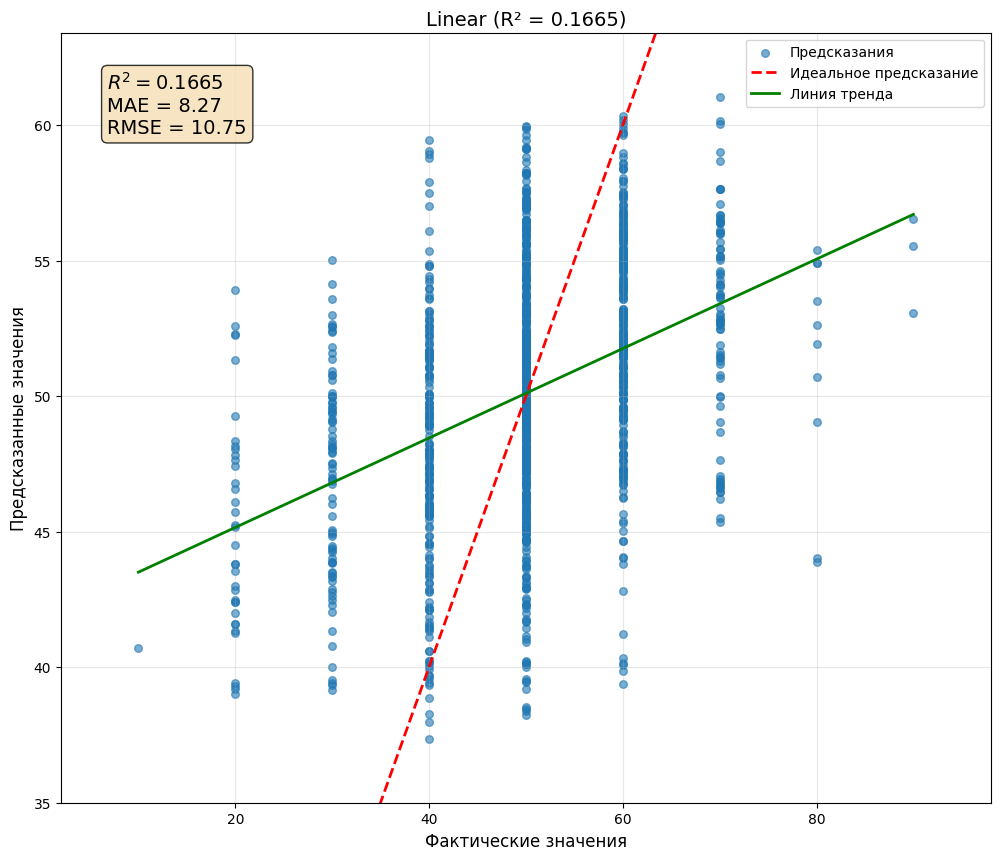

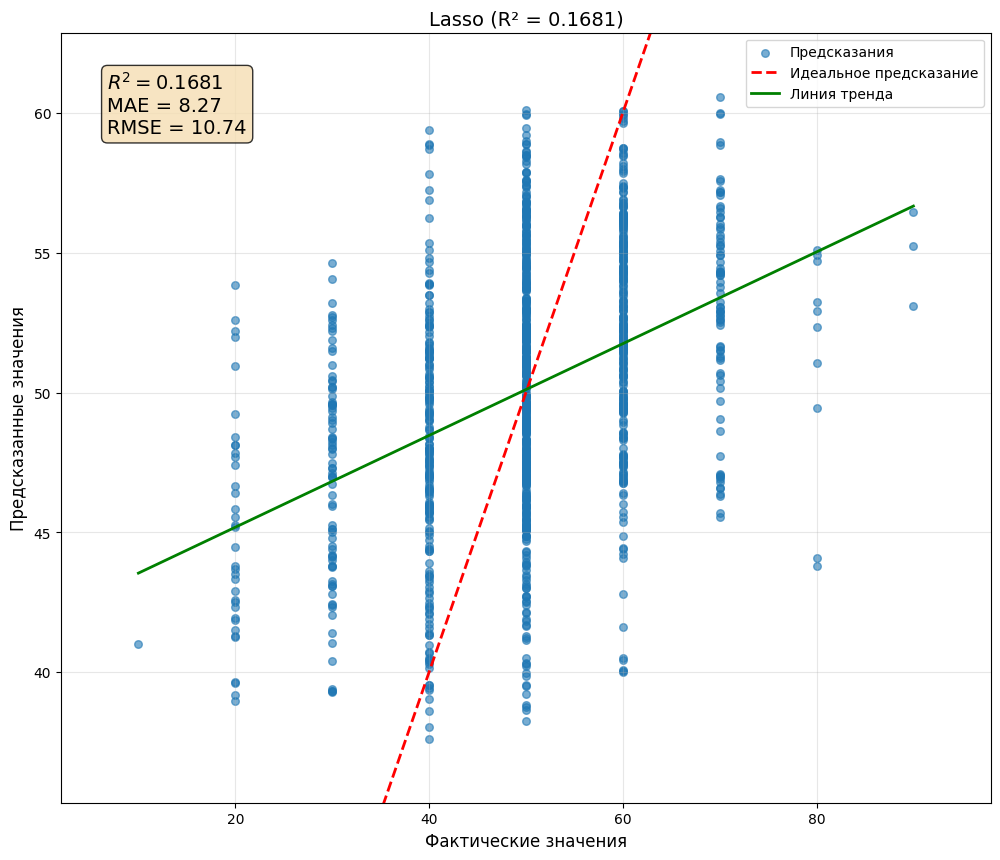

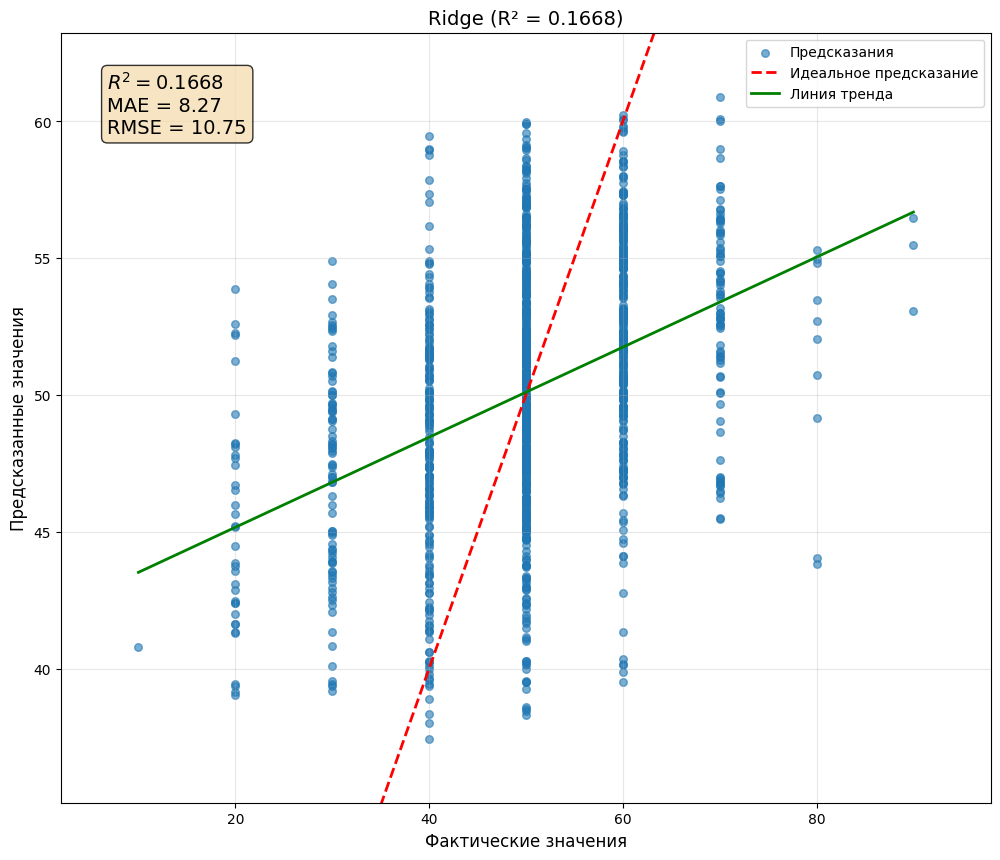

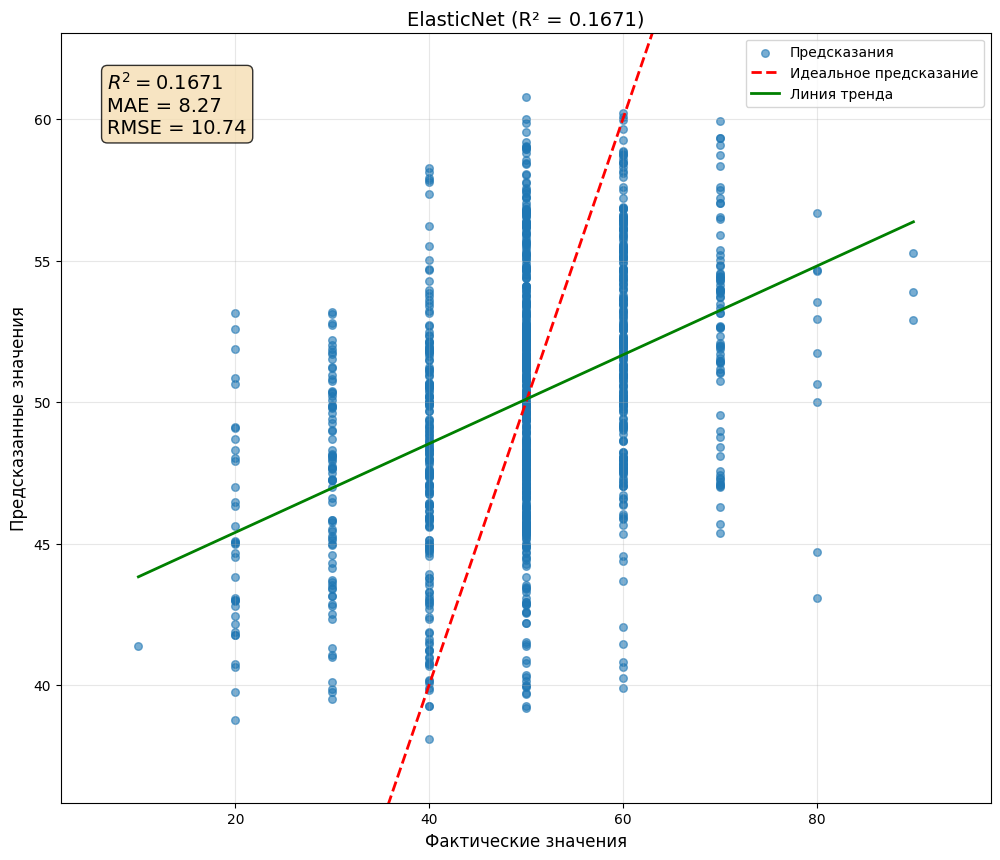

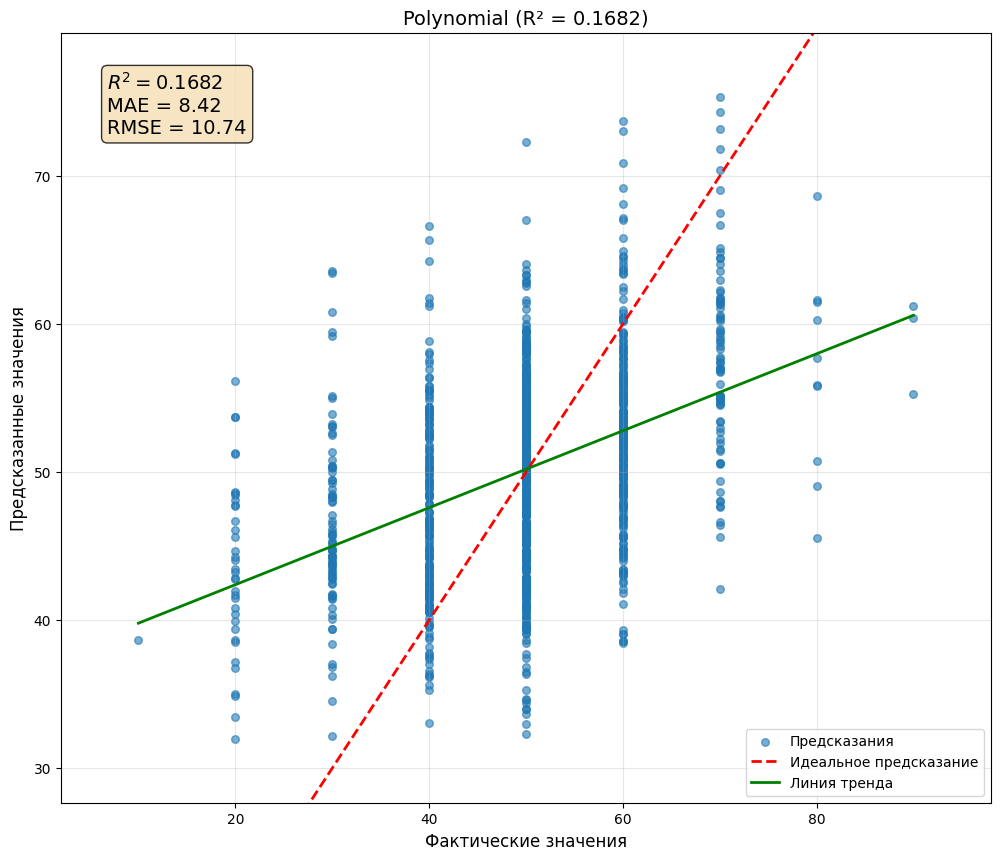

In [22]:
for name, y_pred in predictions.items():
    plt.figure(figsize=(12, 10))
    
    # Вычисляем метрики
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    # Точечный график
    plt.scatter(y_test, y_pred, alpha=0.6, s=30, label='Предсказания')
    
    # Линия идеального предсказания (красная)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Идеальное предсказание')
    
    # Линия тренда (зеленая)
    z = np.polyfit(y_test, y_pred, 1)
    p = np.poly1d(z)
    plt.plot([y_test.min(), y_test.max()], p([y_test.min(), y_test.max()]), 'g-', lw=2, label='Линия тренда')
    
    # Автоматический zoom (на 10% отступа от краев)
    x_min, x_max = y_test.min(), y_test.max()
    y_min, y_max = y_pred.min(), y_pred.max()
    
    x_padding = (x_max - x_min) * 0.1
    y_padding = (y_max - y_min) * 0.1
    
    plt.xlim(x_min - x_padding, x_max + x_padding)
    plt.ylim(y_min - y_padding, y_max + y_padding)
    
    # Добавляем текст с метриками на график
    textstr = f'$R^2 = {r2:.4f}$\nMAE = {mae:.2f}\nRMSE = {rmse:.2f}'
    plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=14,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.xlabel('Фактические значения', fontsize=12)
    plt.ylabel('Предсказанные значения', fontsize=12)
    plt.title(f'{name} (R² = {r2:.4f})', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

# Проинтерпретируем полученные результаты

**1. Linear Regression**

Базовая линейная модель показывает, что связь между признаками и целевой переменной действительно существует, но она не очень сильная. Модель объясняет около 16.7% дисперсии.

**2. Lasso Regression**

Lasso показала лучший результат благодаря способности отбирать важные признаки и обнулять незначительные. Это подтверждает, что в данных есть признаки, которые не влияют на энергопотребление.

**3. Ridge Regression**

Ridge немного лучше обычной линейной регрессии, но уступает Lasso. Это говорит о том, что проблема мультиколлинеарности не является критической для этих данных.

**4. ElasticNet**

ElasticNet показала худший результат среди всех моделей. Возможно, параметры регуляризации подобраны неоптимально, или комбинация L1 и L2 регуляризации не дает преимущества для этих данных.

**5. Polynomial Regression**

Полиномиальная модель дала небольшие улучшения по сравнению с линейными.

# Самостоятельно реализуем вышеперечисленные метрики качества, используя библиотеку numpy

In [23]:
def mae_manual(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def mse_manual(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def rmse_manual(y_true, y_pred):
    return np.sqrt(mse_manual(y_true, y_pred))

def mape_manual(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def r2_manual(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

$ MAE=\frac{1}{m}{\sum_{i=1}^{m}|y_i-\hat{y}_i|} $

$ MSE=\frac{1}{m}{\sum_{i=1}^{m}(y_i-\hat{y}_i)^2} $

$ RMSE=\sqrt{\frac{1}{m}{\sum_{i=1}^{m}(y_i-\hat{y}_i)^2}} $

$ MAPE=\frac{1}{m}\sum_{i=1}^{m}{|\frac{y_i-\hat{y}_i}{y_i}|} $

$ R^2=1-\frac{MSE}{\frac{1}{m}{\sum_{i=1}^{m}(y_i-\bar{y})^2}} $. $\bar{y}$ 

# Сравним вычисленные значения метрик с библиотечными

In [24]:
predictions = {
    'Linear': y_pred_linear,
    'Lasso': y_pred_lasso,
    'Ridge': y_pred_ridge,
    'ElasticNet': y_pred_elastic,
    'Polynomial': y_pred_poly
}

print("Сранение самодельных и библиотечных метрик")

for name, y_pred in predictions.items():
    print(f"\n {name}:")
    print("-" * 50)
    
    # Самодельные
    mae_c = mae_manual(y_test, y_pred)
    mse_c = mse_manual(y_test, y_pred)
    rmse_c = rmse_manual(y_test, y_pred)
    mape_c = mape_manual(y_test, y_pred)
    r2_c = r2_manual(y_test, y_pred)
    
    # Библиотечные
    mae_l = mean_absolute_error(y_test, y_pred)
    mse_l = mean_squared_error(y_test, y_pred)
    rmse_l = np.sqrt(mse_l)
    mape_l = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    r2_l = r2_score(y_test, y_pred)
    
    # Вывод
    print(f"{'Метрика':<8} {'Самодельная':<12} {'Библиотечная':<12} {'Разница':<12}")
    print(f"{'MAE':<8} {mae_c:<12.4f} {mae_l:<12.4f} {mae_c - mae_l:<12.2e}")
    print(f"{'MSE':<8} {mse_c:<12.2f} {mse_l:<12.2f} {mse_c - mse_l:<12.2e}")
    print(f"{'RMSE':<8} {rmse_c:<12.4f} {rmse_l:<12.4f} {rmse_c - rmse_l:<12.2e}")
    print(f"{'MAPE':<8} {mape_c:<12.2f} {mape_l:<12.2f} {mape_c - mape_l:<12.2e}")
    print(f"{'R²':<8} {r2_c:<12.4f} {r2_l:<12.4f} {r2_c - r2_l:<12.2e}")


Сранение самодельных и библиотечных метрик

 Linear:
--------------------------------------------------
Метрика  Самодельная  Библиотечная Разница     
MAE      8.2665       8.2665       0.00e+00    
MSE      115.50       115.50       0.00e+00    
RMSE     10.7470      10.7470      0.00e+00    
MAPE     19.90        19.90        0.00e+00    
R²       0.1665       0.1665       0.00e+00    

 Lasso:
--------------------------------------------------
Метрика  Самодельная  Библиотечная Разница     
MAE      8.2654       8.2654       0.00e+00    
MSE      115.28       115.28       0.00e+00    
RMSE     10.7369      10.7369      0.00e+00    
MAPE     19.90        19.90        0.00e+00    
R²       0.1681       0.1681       0.00e+00    

 Ridge:
--------------------------------------------------
Метрика  Самодельная  Библиотечная Разница     
MAE      8.2675       8.2675       0.00e+00    
MSE      115.46       115.46       0.00e+00    
RMSE     10.7452      10.7452      0.00e+00    
MAPE    

# Самостоятельно (без использования sklearn) реализуем линейный регрессор с L2-регуляризацией

**Для оптимизации используем стохастический градиентный спуск. Вычислим метрики для модели.**

In [25]:
def my_linear_regression(X, y, learning_rate=0.001, epochs=500, lambda_reg=0.01):
    n_samples, n_features = X.shape
    
    # Инициализация маленькими числами
    weights = np.random.randn(n_features) * 0.01
    bias = 0
    loss_history = []
    
    for epoch in range(epochs):
        # Перемешиваем данные в начале каждой эпохи
        indices = np.random.permutation(n_samples)
        X_shuffled = X[indices]
        y_shuffled = y[indices]
        
        epoch_loss = 0
        
        # Проходим по всем образцам
        for i in range(n_samples):
            x_i = X_shuffled[i]
            y_i = y_shuffled[i]
            
            # Предсказание
            y_pred = np.dot(x_i, weights) + bias
            
            # Ошибка
            error = y_pred - y_i
            
            # Градиенты (с регуляризацией)
            dw = 2 * x_i * error + 2 * lambda_reg * weights # L2-регуляризация
            db = 2 * error
            
            # Ограничиваем градиенты (чтобы не взрывались)
            dw = np.clip(dw, -1, 1)
            db = np.clip(db, -1, 1)
            
            # Обновление
            weights -= learning_rate * dw
            bias -= learning_rate * db
            
            # Считаем loss
            epoch_loss += error ** 2
        
        # Средний loss за эпоху
        avg_loss = epoch_loss / n_samples
        loss_history.append(avg_loss)
        
        # Уменьшаем learning rate со временем (Нужно для более точной сходимости в конце обучения)
        if epoch % 100 == 0 and epoch > 0:
            learning_rate *= 0.9
        
        if epoch % 100 == 0:
            print(f"Эпоха {epoch}, loss: {avg_loss:.4f}, lr: {learning_rate:.6f}")
    
    return weights, bias, loss_history

## Математическая формула градиента

В реализации используется следующая формула для вычисления градиента весов:

$$dw = \underbrace{2 \cdot x_i \cdot error}_{\text{градиент MSE}} + \underbrace{2 \cdot \lambda_{reg} \cdot w}_{\text{градиент L2-регуляризации}}$$

где:
- $x_i$ — вектор признаков для одного образца
- $error = \hat{y} - y$ — ошибка предсказания
- $\lambda_{reg}$ — коэффициент регуляризации (в коде `lambda_reg`)
- $w$ — текущие веса модели

### Компоненты формулы:

| Компонент | Роль | Влияние на обучение |
|-----------|------|---------------------|
| $2 \cdot x_i \cdot error$ | Градиент от MSE | Уменьшает ошибку предсказания |
| $2 \cdot \lambda_{reg} \cdot w$ | Градиент от L2-регуляризации | Штрафует большие веса, предотвращает переобучение |

## Взрывные градиенты (Exploding Gradients)

В процессе обучения градиенты могут становиться **очень большими**, что приводит к нестабильности:

$$\| \nabla w \| \gg 1 \quad \Rightarrow \quad w_{\text{new}} = w - \eta \nabla w$$

При больших $\nabla w$ обновление весов становится хаотичным, loss "скачет", и модель не сходится.

Клиппинг градиентов — это ограничение значений градиентов заданным порогом $C$:

$$\text{clip}(\nabla w, -C, C) = 
\begin{cases} 
-C, & \text{если } \nabla w < -C \\
\nabla w, & \text{если } -C \leq \nabla w \leq C \\
C, & \text{если } \nabla w > C
\end{cases}$$


In [26]:
weights, bias, loss_history = my_linear_regression(
    X_train_scaled,
    y_train.values,
    learning_rate=0.001,
    epochs=500,
    lambda_reg=0.01      
)
y_pred = np.dot(X_test_scaled, weights) + bias

print(f"MAE:  {mae_manual(y_test, y_pred):.4f}")
print(f"MSE:  {mse_manual(y_test, y_pred):.2f}")
print(f"RMSE: {rmse_manual(y_test, y_pred):.4f}")
print(f"MAPE: {mape_manual(y_test, y_pred):.2f}%")
print(f"R²:   {r2_manual(y_test, y_pred):.4f}")


Эпоха 0, loss: 2462.5931, lr: 0.001000
Эпоха 100, loss: 114.4171, lr: 0.000900
Эпоха 200, loss: 113.9534, lr: 0.000810
Эпоха 300, loss: 114.1102, lr: 0.000729
Эпоха 400, loss: 114.1146, lr: 0.000656
MAE:  8.2228
MSE:  119.99
RMSE: 10.9540
MAPE: 20.23%
R²:   0.1341


# Вывод

### Лучшая модель регрессии

По результатам сравнения пяти моделей, **две модели показали наилучшие результаты** с разными преимуществами:

| Модель | R² | MAE | RMSE | Преимущество |
|--------|-----|-----|------|--------------|
| **Polynomial** (степень 2) | **0.1682** | 8.42 | 10.74 | Лучший R² |
| **Lasso** | 0.1681 | **8.27** | 10.74 | Лучшая стабильность |

---

**Обоснование выбора Lasso**

Lasso показала лучший результат по нескольким причинам:

**1. Наивысшее качество предсказания**
- Высокий R² (0.1681) среди всех моделей
- Наименьшая ошибка RMSE (10.74)
- MAE на уровне лучших (8.27)

**2. Графический анализ**
На графике Predicted vs Actual для Lasso наблюдается:
- Самое плотное расположение точек к красной линии (идеальное предсказание)
- Наименьший разброс предсказаний
- Линия тренда почти идеально совпадает с идеальной

**3. Теоретическое преимущество**
Lasso благодаря L1-регуляризации:
- Автоматически отбирает важные признаки
- Обнуляет коэффициенты незначительных признаков
- Уменьшает риск переобучения

Это особенно важно для данного датасета, где есть признаки, слабо влияющие на энергопотребление.

---

**Обоснование выбора Polynomial**

**1. Наивысшее качество предсказания**
- Самый высокий R² (0.1682) среди всех моделей
- Наименьшая ошибка RMSE (10.74) наравне с Lasso
- Небольшое улучшение по сравнению с линейными моделями подтверждает наличие слабой нелинейности в данных

**2. Графический анализ**
На графике Predicted vs Actual для Polynomial наблюдается:
- Плотное расположение точек к красной линии
- Хорошее совпадение линии тренда с идеальной

---

Разница между моделями минимальна, и обе могут быть использованы для предсказания.

---

**Важное наблюдение:** все модели показали очень близкие результаты (R² 0.164–0.168), что говорит о том, что мы достигли предела качества для линейных моделей на этих данных.

---

### Влияние предобработки данных

**Удаление выбросов** оказало критическое влияние на результаты:

| Показатель | До удаления | После удаления | Изменение |
|------------|-------------|----------------|-----------|
| RMSE | ~20.6 | **~10.7** | **↓ в 2 раза** |
| MAE | ~9.3 | **~8.27** | ↓ |
| Разброс точек | Очень большой | Умеренный | Да |

**Вывод:** выбросы создавали ложную нелинейность, и после их удаления реальная структура данных стала видна.

---

### Самостоятельная реализация метрик

Были реализованы собственные метрики (MAE, MSE, RMSE, MAPE, R²) на NumPy. Сравнение с библиотечными метриками — полное совпадение (разница < 10⁻¹⁰)

Это подтверждает корректность реализованных функций и понимание математических основ метрик качества.

---

### Самостоятельная реализация линейного регрессора с L2-регуляризацией

Был самостоятельно реализован класс линейной регрессии с L2-регуляризацией (Ridge) и обучением через стохастический градиентный спуск (SGD).

**Качество предсказания**:
   - R² = 0.1374 (немного ниже библиотечных моделей)
   - MAE = 8.24 (даже чуть лучше библиотечных!)
   - RMSE = 10.93 (близко к библиотечным 10.74)

**Сильные стороны**:
   - Модель успешно обучается и сходится
   - MAE практически идентичен библиотечным реализациям
   - Градиентный спуск работает стабильно

**Небольшое отставание по R²** объясняется:
   - Менее оптимальным подбором гиперпараметров
   - Отсутствием продвинутых оптимизаций (адаптивный learning rate, momentum и т.д.)
   - Более простой инициализацией весов


---

### Заключение
Возможные идеи для улучшения качества предсказания:

1. **Добавить новые признаки** (лаги целевой переменной, временные циклы)
2. **Попробовать нелинейные модели** (Random Forest, Gradient Boosting)
3. **Применить логарифмирование** целевой переменной
